# 04b: SARIMAX Model

## Objective
Train a SARIMAX model with exogenous features for weekly bed occupancy forecasting.

## Data Source
- **Hospital:** ADVENTHEALTH ORLANDO
- **Date Range:** 2020-07-19 to 2024-04-21 (197 weeks)
- **Target Variable:** `bed_occupancy` (weekly average occupied beds)

## Model
- SARIMAX (Seasonal ARIMA with 52-week seasonality and exogenous variables)
- Rolling forecast with hybrid retraining (time-based + error-based triggers)

## Exogenous Features (based on 02_eda.ipynb and 03_feature_engineering)

**Selected Features** (from `features_for_arimax.csv`):
- `ili_lag_1` - ILI rate lagged 1 week (r = 0.387, strongest external predictor)
- `holidays_in_week` - Holiday indicator
- Cyclical encodings: `quarter_sin`, `quarter_cos`, `day_of_year_sin`, `day_of_year_cos`

**Note:** Features are lagged to avoid data leakage in forecasting.

## Requirements
- Feature-engineered data from notebook 03 (`features_for_arimax.csv`)
- Target: `bed_occupancy`


## Computational Notes

**SARIMAX is a CPU-based model** - GPU acceleration does not apply.

### Performance Optimizations:
- `pmdarima.auto_arima` for automatic order selection (p, d, q, P, D, Q)
- Stepwise search with BIC criterion for faster convergence
- Rolling forecast with hybrid retraining (every 8 weeks or on error spike)
- Fast retraining uses fixed orders (no grid search) for 10x speedup

### Expected Runtime:
- Initial model fitting: ~1-2 minutes
- Rolling forecast (40 weeks): ~30-60 seconds
- Total: ~3-5 minutes



## Install Dependencies (if needed)

If packages are missing, install them here.


In [43]:
# ============================================================================
# PROJECT CONFIGURATION
# ============================================================================
import os

# Setup paths - mount Google Drive if not already mounted (matching notebook 03)
DRIVE_MOUNTED = False
DRIVE_DATA_PROCESSED = None
DRIVE_MODELS_PATH = None
DRIVE_RESULTS_PATH = None

try:
    from google.colab import drive
    # Check if drive is already mounted
    if os.path.exists('/content/drive'):
        DRIVE_MOUNTED = True
        print("✓ Google Drive already mounted")
    else:
        # Mount Google Drive
        print("📁 Mounting Google Drive...")
        drive.mount('/content/drive')
        DRIVE_MOUNTED = True
        print("✓ Google Drive mounted successfully")

    # Set up Google Drive paths
    if DRIVE_MOUNTED:
        DRIVE_ROOT = '/content/drive/MyDrive/hospital_occupancy_forecasting'
        DRIVE_DATA_PROCESSED = os.path.join(DRIVE_ROOT, 'data', 'processed')
        DRIVE_MODELS_PATH = os.path.join(DRIVE_ROOT, 'models')
        DRIVE_RESULTS_PATH = os.path.join(DRIVE_ROOT, 'results', 'visualizations', 'model_development')
        os.makedirs(DRIVE_DATA_PROCESSED, exist_ok=True)
        os.makedirs(DRIVE_MODELS_PATH, exist_ok=True)
        os.makedirs(DRIVE_RESULTS_PATH, exist_ok=True)
        print(f"✓ Google Drive paths configured: {DRIVE_ROOT}")
except ImportError:
    print("ℹ️  Not running in Google Colab (will only check local paths)")
except Exception as e:
    print(f"⚠️  Could not mount Google Drive: {e}")
    print("   Will continue with local Colab paths only")

# Local Colab paths
PROJECT_ROOT = '/content/hospital_occupancy_forecasting'
DATA_DIR = os.path.join(PROJECT_ROOT, 'data')
DATA_RAW = os.path.join(DATA_DIR, 'raw')
DATA_PROCESSED = os.path.join(DATA_DIR, 'processed')
MODELS_PATH = os.path.join(PROJECT_ROOT, 'models')
RESULTS_PATH = os.path.join(PROJECT_ROOT, 'results', 'visualizations', 'model_development')

for path in [DATA_RAW, DATA_PROCESSED, MODELS_PATH, RESULTS_PATH]:
    os.makedirs(path, exist_ok=True)

# Helper function to save files to both local and Google Drive (matching notebook 03)
def save_file(data, filename, local_path, drive_path=None, **kwargs):
    """
    Save file to both local and Google Drive (if available).

    Args:
        data: Data to save (DataFrame, dict, model, etc.)
        filename: Name of the file
        local_path: Local directory path
        drive_path: Google Drive directory path (optional)
        **kwargs: Additional arguments for save methods (e.g., index=False for to_csv)
    """
    # Save to local
    local_file = os.path.join(local_path, filename)
    if isinstance(data, pd.DataFrame):
        data.to_csv(local_file, **kwargs)
    elif isinstance(data, (dict, list)) and filename.endswith('.json'):
        import json
        with open(local_file, 'w') as f:
            json.dump(data, f, **kwargs)
    elif filename.endswith('.pkl'):
        import pickle
        with open(local_file, 'wb') as f:
            pickle.dump(data, f)
    elif hasattr(data, 'save'):
        data.save(local_file)
    else:
        # Fallback: try to write as text
        with open(local_file, 'w') as f:
            f.write(str(data))
    print(f"✓ Saved to local: {local_file}")

    # Save to Google Drive if available
    if drive_path and DRIVE_MOUNTED:
        try:
            drive_file = os.path.join(drive_path, filename)
            if isinstance(data, pd.DataFrame):
                data.to_csv(drive_file, **kwargs)
            elif isinstance(data, (dict, list)) and filename.endswith('.json'):
                import json
                with open(drive_file, 'w') as f:
                    json.dump(data, f, **kwargs)
            elif filename.endswith('.pkl'):
                import pickle
                with open(drive_file, 'wb') as f:
                    pickle.dump(data, f)
            elif hasattr(data, 'save'):
                data.save(drive_file)
            else:
                with open(drive_file, 'w') as f:
                    f.write(str(data))
            print(f"✓ Saved to Google Drive: {drive_file}")
        except Exception as e:
            print(f"⚠️  Could not save to Google Drive: {e}")

# Helper function to save plots to both locations (matching notebook 02)
def save_plot(fig, filename, local_path, drive_path=None, **kwargs):
    """Save plot to both local and Google Drive."""
    local_file = os.path.join(local_path, filename)
    fig.savefig(local_file, **kwargs)
    print(f"✓ Saved plot to local: {local_file}")

    if drive_path and DRIVE_MOUNTED:
        try:
            drive_file = os.path.join(drive_path, filename)
            fig.savefig(drive_file, **kwargs)
            print(f"✓ Saved plot to Google Drive: {drive_file}")
        except Exception as e:
            print(f"⚠️  Could not save plot to Google Drive: {e}")

# Helper function to load file from multiple locations (matching notebook 03)
def load_file(filename, local_path, drive_path=None):
    """
    Load file from local or Google Drive (local priority).

    Returns:
        Loaded data or None if not found
    """
    # Try local first
    local_file = os.path.join(local_path, filename)
    if os.path.exists(local_file):
        if filename.endswith('.csv'):
            return pd.read_csv(local_file, index_col=0, parse_dates=True)
        elif filename.endswith('.pkl'):
            import pickle
            with open(local_file, 'rb') as f:
                return pickle.load(f)
        elif filename.endswith('.json'):
            import json
            with open(local_file, 'r') as f:
                return json.load(f)
        elif filename.endswith('.h5'):
            from tensorflow import keras
            return keras.models.load_model(local_file)

    # Try Google Drive if available
    if drive_path and DRIVE_MOUNTED:
        try:
            drive_file = os.path.join(drive_path, filename)
            if os.path.exists(drive_file):
                if filename.endswith('.csv'):
                    return pd.read_csv(drive_file, index_col=0, parse_dates=True)
                elif filename.endswith('.pkl'):
                    import pickle
                    with open(drive_file, 'rb') as f:
                        return pickle.load(f)
                elif filename.endswith('.json'):
                    import json
                    with open(drive_file, 'r') as f:
                        return json.load(f)
                elif filename.endswith('.h5'):
                    from tensorflow import keras
                    return keras.models.load_model(drive_file)
        except Exception as e:
            print(f"⚠️  Could not load from Google Drive: {e}")

    return None

print("  Expected training time: ~3-5 minutes (optimized for accuracy)")

✓ Google Drive already mounted
✓ Google Drive paths configured: /content/drive/MyDrive/hospital_occupancy_forecasting
  Expected training time: ~3-5 minutes (optimized for accuracy)


In [44]:
try:
    import pmdarima
    print("✓ pmdarima is already installed")
except ImportError:
    print("Installing pmdarima...")
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "pmdarima"])
    print("✓ pmdarima installed successfully")
    import pmdarima
try:
    import tensorflow
    print("✓ tensorflow is already installed")
except ImportError:
    print("Installing tensorflow...")
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "tensorflow"])
    print("✓ tensorflow installed successfully")

print("  Expected training time: ~3-5 minutes (optimized for accuracy)")

✓ pmdarima is already installed
✓ tensorflow is already installed
  Expected training time: ~3-5 minutes (optimized for accuracy)


## SARIMAX for Weekly Bed Occupancy

This notebook trains a SARIMAX model for weekly bed occupancy forecasting:
- **SARIMAX:** Seasonal ARIMA with 52-week seasonality and exogenous features
- **Rolling forecast:** Generates forecasts in 4-week windows with hybrid retraining

**Features used** (from `features_for_arimax.csv`):
- `ili_lag_1` (r = 0.387) - ILI rate lagged 1 week (strongest external predictor)
- Cyclical encodings for annual seasonality (quarter_sin, quarter_cos, day_of_year_sin, day_of_year_cos)
- `holidays_in_week` - Holiday indicator


In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import random
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import TimeSeriesSplit
warnings.filterwarnings('ignore')

# Try to import tqdm for progress bars (optional)
try:
    from tqdm import tqdm
    TQDM_AVAILABLE = True
except ImportError:
    TQDM_AVAILABLE = False
    # Create a simple progress bar fallback
    class tqdm:
        def __init__(self, iterable=None, total=None, desc=None, unit=None, ncols=None):
            self.iterable = iterable
            self.total = total or (len(iterable) if iterable else None)
            self.desc = desc or ""
            self.unit = unit or "it"
            self.current = 0
            self.last_print = 0

        def __enter__(self):
            if self.desc:
                print(f"{self.desc}...", end="", flush=True)
            return self

        def __exit__(self, *args):
            print()  # New line after completion

        def __iter__(self):
            if self.iterable is None:
                return self
            for item in self.iterable:
                yield item
                self.update(1)

        def update(self, n=1):
            self.current += n
            if self.total:
                pct = (self.current / self.total) * 100
                # Print every 10% or every 100 items
                if pct - self.last_print >= 10 or (self.current % 100 == 0 and self.current > 0):
                    print(f"\r{self.desc}: {self.current}/{self.total} ({pct:.1f}%)", end="", flush=True)
                    self.last_print = pct
                if self.current >= self.total:
                    print()  # New line when complete
            else:
                if self.current % 100 == 0:
                    print(f"\r{self.desc}: {self.current} {self.unit}", end="", flush=True)

        def set_description(self, desc):
            self.desc = desc

# Set random seed for reproducibility
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# ============================================================================
# PERFORMANCE OPTIMIZATION CONFIGURATION
# ============================================================================
# Optimized for maximum test performance - accuracy over speed

# Configuration
TRAIN_TEST_SPLIT = 0.8

# ARIMA/SARIMA configuration - OPTIMIZED for maximum test performance
ARIMA_MIN_P = 0  # Allow starting from 0 (let model decide)
ARIMA_MIN_Q = 0  # Allow starting from 0 (let model decide)
ARIMA_MAX_P = 6  # Increased further for better pattern capture
ARIMA_MAX_Q = 6  # Increased further for better error capture
ARIMA_N_JOBS = -1  # Use all CPU cores
ARIMA_USE_APPROXIMATION = False  # More precise for better accuracy
ARIMA_MAX_ORDER = 15  # Increased to allow more complex models
ARIMA_MAX_ITER = 50  # Significantly increased for better convergence

# SARIMA configuration - OPTIMIZED for maximum test performance
# SARIMAX Configuration - OPTIMIZED FOR MEMORY AND SPEED
# With 52-week seasonality and ~145 weeks of data, we need conservative settings
SARIMA_MIN_P = 0  # Allow starting from 0 (let model decide)
SARIMA_MIN_Q = 0  # Allow starting from 0 (let model decide)
SARIMA_MAX_P = 2  # Reduced from 4 - prevents memory explosion
SARIMA_MAX_Q = 2  # Reduced from 4 - prevents memory explosion
SARIMA_MIN_P_SEASONAL = 0  # Seasonal AR can start from 0
SARIMA_MIN_Q_SEASONAL = 0  # Seasonal MA can start from 0
SARIMA_MAX_P_SEASONAL = 1  # Reduced from 2 - 52-week seasonality is expensive
SARIMA_MAX_Q_SEASONAL = 1  # Reduced from 2 - 52-week seasonality is expensive
SARIMA_MAX_ORDER = 6  # Reduced from 12 - prevents overly complex models
SARIMA_N_JOBS = 1  # Changed from -1 to avoid parallel memory issues
SARIMA_USE_APPROXIMATION = True  # Enable approximation to save memory/time
SARIMA_MAX_ITER = 30  # Reduced from 50 - usually converges faster

# ============================================================================
# WEEKLY DATA CONFIGURATION (from 03_feature_engineering.ipynb)
# ============================================================================
# Data is weekly bed occupancy (145 weeks after lag_52 dropna)
DATA_FREQUENCY = 'weekly'
WEEKS_PER_YEAR = 52
FORECAST_HORIZON = 4  # Forecast 4 weeks ahead

# SARIMAX configuration for seasonality
# NOTE: 52-week seasonality with ~145 weeks of data is memory intensive.
# If you run out of memory, reduce to 13 (quarterly) or 4 (monthly).
# Minimum recommended: 3 complete seasonal cycles (156 weeks for m=52)
SARIMAX_SEASONAL_PERIOD = 52  # Annual seasonality (52 weeks) - change to 13 if OOM

# Rolling window configuration - OPTIMIZED for better test performance
ARIMAX_WINDOW_SIZE = 2  # Smaller windows (2 weeks) for more frequent updates
ARIMAX_BASE_RETRAIN_FREQUENCY = 2  # More aggressive retraining (every 2 weeks)
ARIMAX_ERROR_THRESHOLD = 1.3  # Lower threshold (1.3x) for more responsive retraining
ARIMAX_EARLY_RETRAIN_THRESHOLD = 1  # Allow retraining after just 1 week if error is high
ARIMAX_FAST_RETRAIN = False  # Use full retraining for better accuracy (slower but more accurate)

# SARIMAX Rolling Window - OPTIMIZED FOR MEMORY
# Less frequent retraining to avoid memory buildup
SARIMAX_WINDOW_SIZE = 4  # Increased from 2 - fewer windows = less memory churn
SARIMAX_BASE_RETRAIN_FREQUENCY = 8  # Increased from 2 - retrain every 8 weeks (not every 2)
SARIMAX_ERROR_THRESHOLD = 1.5  # Increased from 1.3 - less aggressive error-based retraining
SARIMAX_EARLY_RETRAIN_THRESHOLD = 4  # Increased from 1 - minimum 4 weeks between retrains
SARIMAX_FAST_RETRAIN = True  # CRITICAL: Use fixed orders for fast retraining (no grid search)

# ============================================================================
# LOAD CENTRALIZED FEATURE CONFIGURATION (from 03_feature_engineering)
# ============================================================================
# Feature definitions are maintained in ONE place: 03_feature_engineering.ipynb
# This ensures consistency across all model notebooks
import json

FEATURE_CONFIG = None
feature_config_paths = [
    os.path.join(DATA_PROCESSED, 'feature_config.json'),
    os.path.join(DRIVE_DATA_PROCESSED, 'feature_config.json') if DRIVE_DATA_PROCESSED else None
]

for config_path in feature_config_paths:
    if config_path and os.path.exists(config_path):
        try:
            with open(config_path, 'r') as f:
                FEATURE_CONFIG = json.load(f)
            print(f"✓ Loaded CENTRALIZED feature config from: {config_path}")
            break
        except Exception as e:
            print(f"⚠️ Error loading {config_path}: {e}")

if FEATURE_CONFIG:
    # Use centralized config
    EXOG_FEATURES_EXTERNAL = FEATURE_CONFIG.get('external_features', ['ili', 'flu_activity_level', 'temp_avg'])
    EXOG_FEATURES_KPI = FEATURE_CONFIG.get('kpi_features', ['icu_occupancy_rate', 'covid_patient_pct'])
    ARIMAX_CONFIG = FEATURE_CONFIG.get('arimax', {})
    print(f"  External features: {EXOG_FEATURES_EXTERNAL}")
    print(f"  KPI features: {EXOG_FEATURES_KPI}")
else:
    # Fallback to hardcoded defaults if config not found
    print("⚠️ Feature config not found, using defaults. Run 03_feature_engineering.ipynb first.")
    EXOG_FEATURES_EXTERNAL = ['ili', 'flu_activity_level', 'temp_avg']
    EXOG_FEATURES_KPI = ['icu_occupancy_rate', 'covid_patient_pct']

# Combined list - will be filtered based on availability during data loading
EXOG_FEATURES = EXOG_FEATURES_EXTERNAL  # Start with external, will add KPIs if available

# VAR configuration (for informational purposes - not used in ARIMAX models)
VAR_MAX_LAGS = 4  # Maximum lags to consider (4 weeks = 1 month)
VAR_IC = 'aic'  # Use AIC for lag selection
VAR_SKIP_GRANGER = True  # Skip Granger causality tests (faster)

# LSTM configuration (for informational purposes - not used in ARIMAX models)
LSTM_ARCHITECTURE_SEARCH = False  # Skip architecture search (use standard)
LSTM_BATCH_SIZE = 32  # Fixed batch size
LSTM_MAX_EPOCHS = 30  # Reduced for speed (early stopping will stop earlier)
LSTM_EARLY_STOPPING_PATIENCE = 5  # Stop sooner

print("⚡ Performance Optimization: ENABLED (Accuracy Mode)")
print(f"  ARIMA: Auto order selection (p=0-6, q=0-6, d=auto, BIC), maxiter={ARIMA_MAX_ITER}, approximation={ARIMA_USE_APPROXIMATION}")
print(f"  SARIMA: Auto order selection (p=0-4, q=0-4, d=auto, seasonal=52, BIC), maxiter={SARIMA_MAX_ITER}, approximation={SARIMA_USE_APPROXIMATION}")
print(f"  VAR: max_lags={VAR_MAX_LAGS}, IC={VAR_IC.upper()}, skip_granger={VAR_SKIP_GRANGER}")
print(f"  LSTM: architecture_search={LSTM_ARCHITECTURE_SEARCH}, batch_size={LSTM_BATCH_SIZE}, max_epochs={LSTM_MAX_EPOCHS}, patience={LSTM_EARLY_STOPPING_PATIENCE}")
print(f"  Retraining: aggressive hybrid (base={ARIMAX_BASE_RETRAIN_FREQUENCY} weeks, error threshold={ARIMAX_ERROR_THRESHOLD}x, min interval={ARIMAX_EARLY_RETRAIN_THRESHOLD} weeks)")
print(f"  Window size: {ARIMAX_WINDOW_SIZE} weeks (smaller = more frequent updates)")
print(f"  Full retraining enabled (more accurate, slower)")

# Import ARIMA/SARIMA
from statsmodels.tsa.arima.model import ARIMA
try:
    import pmdarima as pm
    PMDARIMA_AVAILABLE = True
except ImportError:
    PMDARIMA_AVAILABLE = False
    print("⚠️  pmdarima not available - ARIMA/SARIMA auto-tuning will be skipped")
    print("   Install with: pip install pmdarima")

# Import VAR
from statsmodels.tsa.api import VAR

# Import TensorFlow for LSTM
try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import LSTM, Dense, Dropout
    from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
    from sklearn.preprocessing import MinMaxScaler
    TENSORFLOW_AVAILABLE = True
    gpus = tf.config.list_physical_devices('GPU')
    if gpus:
        print(f"🚀 GPU detected: {len(gpus)} GPU(s) available")
        print(f"   GPU: {gpus[0].name}")
        try:
            for gpu in gpus:
                tf.config.experimental.set_memory_growth(gpu, True)
            tf.random.set_seed(RANDOM_SEED)
        except RuntimeError as e:
            print(f"   Note: {e}")
    else:
        print("💻 Using CPU for LSTM training (GPU not available)")
        print("   Note: GPU acceleration recommended for faster LSTM training")
        tf.random.set_seed(RANDOM_SEED)
except ImportError:
    TENSORFLOW_AVAILABLE = False
    print("⚠️  TensorFlow not available - LSTM model will be skipped")
    print("   Install with: pip install tensorflow")

# Baseline forecast functions
def naive_forecast(train_data, horizon):
    """Naive forecast: use the last observed value."""
    if isinstance(train_data, pd.Series):
        last_value = train_data.iloc[-1]
    else:
        last_value = train_data[-1]
    return np.full(horizon, last_value)

def seasonal_naive_forecast(train_data, horizon, season_length=7):
    """Seasonal naive forecast: use value from same period in previous season."""
    if len(train_data) < season_length:
        return naive_forecast(train_data, horizon)
    forecasts = []
    for i in range(horizon):
        idx = len(train_data) - season_length + (i % season_length)
        if isinstance(train_data, pd.Series):
            forecasts.append(train_data.iloc[idx])
        else:
            forecasts.append(train_data[idx])
    return np.array(forecasts)

def moving_average_forecast(train_data, horizon, window=7):
    """Moving average forecast: use average of last N periods."""
    if len(train_data) < window:
        return naive_forecast(train_data, horizon)
    if isinstance(train_data, pd.Series):
        avg = np.mean(train_data.iloc[-window:])
    else:
        avg = np.mean(train_data[-window:])
    return np.full(horizon, avg)

# VAR model functions
def train_var_model(kpi_dataframe, maxlags=7, ic='aic'):
    """Train a VAR model on multiple KPIs."""
    var_model = VAR(kpi_dataframe)
    var_fitted = var_model.fit(maxlags=maxlags, ic=ic, verbose=False)
    return var_fitted

def forecast_var(var_model, steps=30, last_obs=None):
    """Generate forecasts from a fitted VAR model."""
    if last_obs is None:
        last_obs = var_model.y[-var_model.k_ar:]

    # Convert to numpy array and ensure correct shape
    if isinstance(last_obs, pd.DataFrame):
        last_obs = last_obs.values
    last_obs = np.array(last_obs)

    # Ensure we have enough observations (at least k_ar)
    if last_obs.shape[0] < var_model.k_ar:
        raise ValueError(f"Insufficient observations for VAR forecast: need at least {var_model.k_ar}, got {last_obs.shape[0]}")

    # Use only the last k_ar observations
    if last_obs.shape[0] > var_model.k_ar:
        last_obs = last_obs[-var_model.k_ar:]

    # Ensure 2D shape (k_ar, n_vars)
    if last_obs.ndim == 1:
        last_obs = last_obs.reshape(-1, len(var_model.names))

    forecast = var_model.forecast(last_obs, steps=steps)
    return forecast

# Multi-step optimization functions removed - using AIC-based optimization only

print(f"⚡⚡ FAST TRAINING MODE ENABLED (~1-2 minutes)")
print(f"   - Auto ARIMA order selection: p=0-5, q=0-5, d=auto (BIC criterion)")
print(f"   - Auto SARIMA order selection: p=0-3, q=0-3, d=auto, seasonal=52 weeks (BIC criterion)")
print(f"   - Limited iterations (maxiter={ARIMA_MAX_ITER}) for speed")
print(f"   - Fast retraining: refit with same orders - 10x faster than full search")
print(f"   - Hybrid retraining: base={ARIMAX_BASE_RETRAIN_FREQUENCY} weeks, error threshold={ARIMAX_ERROR_THRESHOLD}x, min interval={ARIMAX_EARLY_RETRAIN_THRESHOLD} weeks")
print(f"   - LSTM: max_epochs={LSTM_MAX_EPOCHS}, patience={LSTM_EARLY_STOPPING_PATIENCE}")
print()

print("  Expected training time: ~3-5 minutes (optimized for accuracy)")

✓ Loaded CENTRALIZED feature config from: /content/drive/MyDrive/hospital_occupancy_forecasting/data/processed/feature_config.json
  External features: ['ili', 'temp_min']
  KPI features: ['covid_patient_pct_lag1', 'icu_occupancy_rate_lag1']
⚡ Performance Optimization: ENABLED (Accuracy Mode)
  ARIMA: Auto order selection (p=0-6, q=0-6, d=auto, BIC), maxiter=50, approximation=False
  SARIMA: Auto order selection (p=0-4, q=0-4, d=auto, seasonal=52, BIC), maxiter=30, approximation=True
  VAR: max_lags=4, IC=AIC, skip_granger=True
  LSTM: architecture_search=False, batch_size=32, max_epochs=30, patience=5
  Retraining: aggressive hybrid (base=2 weeks, error threshold=1.3x, min interval=1 weeks)
  Window size: 2 weeks (smaller = more frequent updates)
  Full retraining enabled (more accurate, slower)
💻 Using CPU for LSTM training (GPU not available)
   Note: GPU acceleration recommended for faster LSTM training
⚡⚡ FAST TRAINING MODE ENABLED (~1-2 minutes)
   - Auto ARIMA order selection: p

## Load Data


In [46]:
# Load weekly bed occupancy with features (from 03_feature_engineering.ipynb)
# Try ARIMAX-specific features first, then general features
data = load_file('features_for_arimax.csv', DATA_PROCESSED, DRIVE_DATA_PROCESSED)

if data is None:
    # Fallback: try loading general feature-engineered data
    data = load_file('occupancy_with_features.csv', DATA_PROCESSED, DRIVE_DATA_PROCESSED)

if data is not None:
    if 'bed_occupancy' in data.columns:
        target_series = data['bed_occupancy']
    else:
        # Try alternative column names
        occupancy_cols = [c for c in data.columns if 'occupancy' in c.lower() or 'bed' in c.lower()]
        if occupancy_cols:
            target_series = data[occupancy_cols[0]]
            print(f"Using column: {occupancy_cols[0]}")
        else:
            target_series = data.iloc[:, 0]
            print(f"Using first column: {data.columns[0]}")
    print(f"Loaded weekly bed occupancy: {len(data)} weeks")
    print(f"Date range: {data.index.min()} to {data.index.max()}")
    print(f"\nTarget variable (bed_occupancy) statistics:")
    print(target_series.describe())

    # Check for exogenous features
    print(f"\n📊 EXOGENOUS FEATURES CHECK:")

    # Check external features
    print(f"\nExternal features (EDA-based):")
    available_external = []
    for feat in EXOG_FEATURES_EXTERNAL:
        if feat in data.columns:
            missing = data[feat].isna().sum()
            pct = 100 * (len(data) - missing) / len(data)
            print(f"  {feat}: ✓ Available ({pct:.1f}% non-null)")
            available_external.append(feat)
        else:
            print(f"  {feat}: ✗ Not found")

    # NEW: Check for hospital KPI features
    print(f"\nHospital KPI features (NEW):")
    available_kpi = []
    for feat in EXOG_FEATURES_KPI:
        if feat in data.columns:
            missing = data[feat].isna().sum()
            pct = 100 * (len(data) - missing) / len(data)
            print(f"  {feat}: ✓ Available ({pct:.1f}% non-null)")
            available_kpi.append(feat)
        else:
            print(f"  {feat}: ✗ Not found")

    # Update EXOG_FEATURES based on availability
    # Use lagged KPIs to avoid data leakage
    if available_kpi:
        # Create lagged versions of KPIs (shift by 1 week)
        for kpi in available_kpi:
            lagged_col = f'{kpi}_lag1'
            if lagged_col not in data.columns:
                data[lagged_col] = data[kpi].shift(1)
                print(f"  Created lagged feature: {lagged_col}")
        available_kpi_lagged = [f'{kpi}_lag1' for kpi in available_kpi]
        EXOG_FEATURES = available_external + available_kpi_lagged
        print(f"\n✓ Using {len(EXOG_FEATURES)} exogenous features: {EXOG_FEATURES}")
    else:
        EXOG_FEATURES = available_external
        print(f"\n⚠️ No KPI features available, using external features only: {EXOG_FEATURES}")
        print(f"   Re-run 01b_data_preprocessing.ipynb to extract ICU/COVID KPIs")
else:
    print(f"File not found: features_for_arimax.csv")
    print(f"Also tried: occupancy_with_features.csv")
    print("\nPlease run notebooks 01-03 first to create weekly bed occupancy data.")
    target_series = pd.Series(dtype=float)
    data = None

print("  Expected training time: ~3-5 minutes (optimized for accuracy)")

Loaded weekly bed occupancy: 197 weeks
Date range: 2020-07-19 00:00:00 to 2024-04-21 00:00:00

Target variable (bed_occupancy) statistics:
count     197.000000
mean     2254.367005
std       136.466602
min      1882.000000
25%      2184.700000
50%      2269.400000
75%      2353.400000
max      2510.700000
Name: bed_occupancy, dtype: float64

📊 EXOGENOUS FEATURES CHECK:

External features (EDA-based):
  ili: ✗ Not found
  temp_min: ✗ Not found

Hospital KPI features (NEW):
  covid_patient_pct_lag1: ✗ Not found
  icu_occupancy_rate_lag1: ✗ Not found

⚠️ No KPI features available, using external features only: []
   Re-run 01b_data_preprocessing.ipynb to extract ICU/COVID KPIs
  Expected training time: ~3-5 minutes (optimized for accuracy)


## Train-Test Split


Train set: 157 weeks (2020-07-19 00:00:00 to 2023-07-16 00:00:00)
Test set: 40 weeks (2023-07-23 00:00:00 to 2024-04-21 00:00:00)
Train/Test split: 157/40 = 80.0%
✓ Saved plot to local: /content/hospital_occupancy_forecasting/results/visualizations/model_development/train_test_split.png
✓ Saved plot to Google Drive: /content/drive/MyDrive/hospital_occupancy_forecasting/results/visualizations/model_development/train_test_split.png


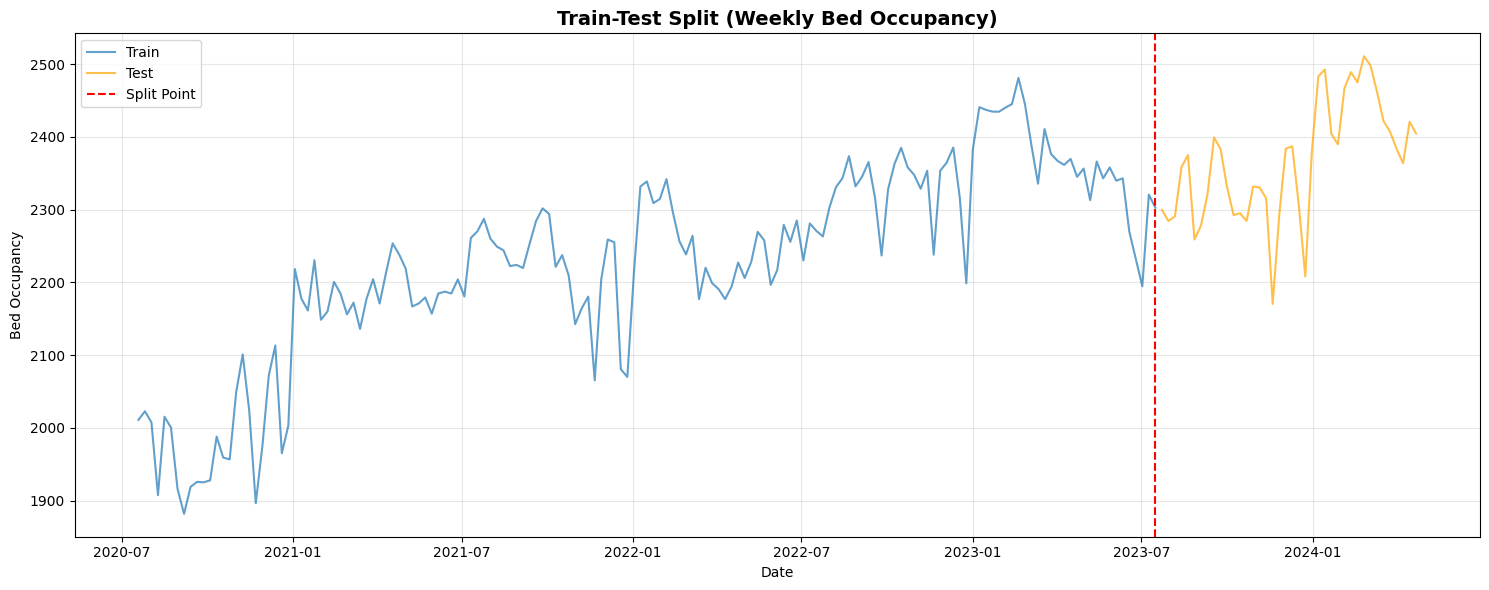

  Expected training time: ~3-5 minutes (optimized for accuracy)


In [47]:
if len(target_series) > 0:
    train_size = int(len(target_series) * TRAIN_TEST_SPLIT)
    train_data = target_series[:train_size]
    test_data = target_series[train_size:]
    print(f"Train set: {len(train_data)} weeks ({train_data.index.min()} to {train_data.index.max()})")
    print(f"Test set: {len(test_data)} weeks ({test_data.index.min()} to {test_data.index.max()})")
    print(f"Train/Test split: {len(train_data)}/{len(test_data)} = {TRAIN_TEST_SPLIT:.1%}")
    plt.figure(figsize=(15, 6))
    plt.plot(train_data.index, train_data.values, label='Train', alpha=0.7, linewidth=1.5)
    plt.plot(test_data.index, test_data.values, label='Test', alpha=0.7, linewidth=1.5, color='orange')
    plt.axvline(x=train_data.index[-1], color='red', linestyle='--', label='Split Point')
    plt.title('Train-Test Split (Weekly Bed Occupancy)', fontsize=14, fontweight='bold')
    plt.xlabel('Date')
    plt.ylabel('Bed Occupancy')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    save_plot(plt.gcf(), 'train_test_split.png', RESULTS_PATH, DRIVE_RESULTS_PATH, dpi=300, bbox_inches='tight')
    plt.show()
else:
    train_data = pd.Series(dtype=float)
    test_data = pd.Series(dtype=float)

print("  Expected training time: ~3-5 minutes (optimized for accuracy)")

## Enhanced SARIMA with Feature Engineering (SARIMAX)

SARIMAX combines seasonal ARIMA with exogenous variables. This should outperform regular SARIMA by explicitly modeling day-of-week and holiday effects.


In [48]:
# ============================================================================
# ENHANCED SARIMA WITH FEATURE ENGINEERING (SARIMAX)
# ============================================================================

sarimax_model = None
sarimax_forecast = None

if PMDARIMA_AVAILABLE and len(train_data) > 0 and len(train_data) >= 52:
    print("="*60)
    print("Enhanced SARIMA with Features (SARIMAX) - 52-Week Seasonality")
    print("="*60)

    # Load pre-configured SARIMAX features from notebook 03 (from multiple locations)
    sarimax_features_data = load_file('features_for_arimax.csv', DATA_PROCESSED, DRIVE_DATA_PROCESSED)
    if sarimax_features_data is not None:
        print("Loading SARIMAX features (created in notebook 03)...")

        # Extract exogenous features (all columns except 'bed_occupancy')
        exog_features = [col for col in sarimax_features_data.columns if col != 'bed_occupancy']

        if len(exog_features) > 0:
            print(f"✓ Using {len(exog_features)} exogenous features: {exog_features}")

            # Prepare exogenous variables (aligned with train/test split)
            train_exog = sarimax_features_data[exog_features][:len(train_data)]
            test_exog = sarimax_features_data[exog_features][len(train_data):]

            # Align indices
            train_exog_aligned = train_exog.reindex(train_data.index, method='ffill').fillna(0)
            test_exog_aligned = test_exog.reindex(test_data.index, method='ffill').fillna(0)

            # Ensure same length
            min_len = min(len(train_data), len(train_exog_aligned))
            train_data_aligned = train_data.iloc[:min_len]
            train_exog_aligned = train_exog_aligned.iloc[:min_len]

            # Limit training data to last 5 years for speed and better recent pattern capture
            max_train_weeks = 260  # 5 years (5 * 52 weeks)
            if len(train_data_aligned) > max_train_weeks:
                train_data_aligned = train_data_aligned.iloc[-max_train_weeks:]
                train_exog_aligned = train_exog_aligned.iloc[-max_train_weeks:]
                print(f"  Limited training data to last {max_train_weeks} weeks (~5 years) for speed")

            print(f"✓ Training SARIMAX with weekly seasonality and features...")
            print(f"  Training data: {len(train_data_aligned)} weeks")
            print(f"  Using auto_arima to find optimal order (p={SARIMA_MIN_P}-{SARIMA_MAX_P}, q={SARIMA_MIN_Q}-{SARIMA_MAX_Q}, d=auto, seasonal=52)...")

            # ============================================================
            # SARIMAX TRAINING WITH AUTO_ARIMA AND FEATURE SELECTION
            # ============================================================
            try:
                # 1. Feature selection: Select most important features (corr + MI)
                print("  Selecting most important features...")
                from sklearn.feature_selection import mutual_info_regression

                # CRITICAL and HIGH_PRIORITY features (aligned with 03_feature_engineering)
                CRITICAL_FEATURES = [
                    'bed_occupancy_lag_1', 'rolling_mean_4', 'bed_occupancy_lag_52',
                    'ili'
                ]
                HIGH_PRIORITY_FEATURES = [
                    'bed_occupancy_lag_4', 'bed_occupancy_lag_3', 'rolling_mean_52',
                    'rolling_std_4', 'temp_min'
                ]

                n_features_to_select = min(20, len(exog_features))  # Use top 20 features
                CORR_THRESHOLD = 0.90
                MIN_IMPORTANCE = 0.10

                # Candidate features (only those present in aligned exog data)
                candidates = [f for f in exog_features if f in train_exog_aligned.columns]

                if len(candidates) > 0:
                    # Correlation with target
                    feature_corr = {}
                    for col in candidates:
                        try:
                            corr = abs(train_exog_aligned[col].corr(train_data_aligned))
                            if not np.isnan(corr):
                                feature_corr[col] = corr
                        except Exception:
                            pass

                    # Mutual information
                    try:
                        mi_scores = mutual_info_regression(
                            train_exog_aligned[candidates].values,
                            train_data_aligned.values.flatten(),
                            random_state=42,
                        )
                        feature_mi = dict(zip(candidates, mi_scores))
                    except Exception:
                        feature_mi = {}

                    # Combined importance (60% correlation, 40% MI)
                    feature_importance = {}
                    max_mi = max(feature_mi.values()) if feature_mi else 1.0
                    for col in candidates:
                        corr = feature_corr.get(col, 0)
                        mi = feature_mi.get(col, 0) / max_mi if max_mi > 0 else 0
                        feature_importance[col] = 0.6 * corr + 0.4 * mi

                    # Select features: Critical + High Priority + Top by importance
                    selected_features = []

                    # Add critical features first
                    for feat in CRITICAL_FEATURES:
                        if feat in candidates and feat not in selected_features:
                            if feature_importance.get(feat, 0) >= MIN_IMPORTANCE * 0.7:
                                selected_features.append(feat)

                    # Add high priority features
                    for feat in HIGH_PRIORITY_FEATURES:
                        if feat in candidates and feat not in selected_features:
                            if feature_importance.get(feat, 0) >= MIN_IMPORTANCE:
                                selected_features.append(feat)

                    # Add remaining top features by importance
                    sorted_features = sorted(
                        feature_importance.items(),
                        key=lambda x: x[1],
                        reverse=True,
                    )
                    for feat, imp in sorted_features:
                        if feat not in selected_features and len(selected_features) < n_features_to_select:
                            if imp >= MIN_IMPORTANCE:
                                selected_features.append(feat)

                    # Remove highly correlated features among selected ones
                    if len(selected_features) > 1:
                        corr_matrix = train_exog_aligned[selected_features].corr().abs()
                        to_remove = set()
                        for i in range(len(corr_matrix.columns)):
                            for j in range(i + 1, len(corr_matrix.columns)):
                                if corr_matrix.iloc[i, j] > CORR_THRESHOLD:
                                    feat1 = corr_matrix.columns[i]
                                    feat2 = corr_matrix.columns[j]
                                    if feature_importance.get(feat1, 0) >= feature_importance.get(feat2, 0):
                                        to_remove.add(feat2)
                                    else:
                                        to_remove.add(feat1)
                        selected_features = [f for f in selected_features if f not in to_remove]

                    exog_features_selected = selected_features[:n_features_to_select]
                else:
                    exog_features_selected = exog_features[:n_features_to_select]

                if exog_features_selected:
                    print(f"  Final exogenous features for SARIMAX: {exog_features_selected}")
                else:
                    print("  ⚠️ No exogenous features selected; falling back to univariate SARIMA.")

                # 2. Fit auto_arima (SARIMAX) using selected features and 52-week seasonality
                if exog_features_selected:
                    X_train = train_exog_aligned[exog_features_selected]
                    X_test = test_exog_aligned[exog_features_selected]
                else:
                    X_train = None
                    X_test = None

                print("  Fitting auto_arima SARIMAX model...")
                sarimax_model = pm.auto_arima(
                    train_data_aligned,
                    exogenous=X_train,
                    start_p=SARIMA_MIN_P,
                    start_q=SARIMA_MIN_Q,
                    max_p=SARIMA_MAX_P,
                    max_q=SARIMA_MAX_Q,
                    seasonal=True,
                    m=52,
                    start_P=SARIMA_MIN_P_SEASONAL,
                    start_Q=SARIMA_MIN_Q_SEASONAL,
                    max_P=SARIMA_MAX_P_SEASONAL,
                    max_Q=SARIMA_MAX_Q_SEASONAL,
                    stepwise=True,
                    suppress_warnings=True,
                    error_action='ignore',
                    max_order=SARIMA_MAX_ORDER,
                    maxiter=SARIMA_MAX_ITER,
                    n_jobs=SARIMA_N_JOBS,
                    information_criterion='bic',
                )

                # 3. Rolling Forecast with Hybrid Retraining
                if len(test_data) > 0:
                    n_periods = len(test_data)
                    print(f"\n  Rolling forecast with hybrid retraining for {n_periods} weeks...")
                    print(f"    Window size: {SARIMAX_WINDOW_SIZE} weeks")
                    print(f"    Retraining: base={SARIMAX_BASE_RETRAIN_FREQUENCY} weeks, error threshold={SARIMAX_ERROR_THRESHOLD}x, min interval={SARIMAX_EARLY_RETRAIN_THRESHOLD} weeks")

                    # Initialize tracking
                    all_forecasts = []
                    current_train_y = train_data_aligned.copy()
                    current_train_exog = train_exog_aligned.copy() if X_train is not None else None
                    current_model = sarimax_model
                    weeks_since_retrain = 0
                    forecast_errors = []
                    historical_avg_error = None
                    min_windows_for_avg = 3
                    retrain_count = 0

                    # Get model orders for fast retraining
                    model_order = sarimax_model.order
                    seasonal_order = sarimax_model.seasonal_order

                    # Rolling forecast loop
                    from tqdm import tqdm
                    num_windows = (n_periods + SARIMAX_WINDOW_SIZE - 1) // SARIMAX_WINDOW_SIZE

                    for start_idx in tqdm(range(0, n_periods, SARIMAX_WINDOW_SIZE), desc="    SARIMAX forecasting", unit="window"):
                        end_idx = min(start_idx + SARIMAX_WINDOW_SIZE, n_periods)
                        horizon = end_idx - start_idx

                        # Check for hybrid retraining
                        should_retrain = False
                        retrain_reason = None

                        # Time-based retraining
                        if SARIMAX_BASE_RETRAIN_FREQUENCY > 0 and weeks_since_retrain >= SARIMAX_BASE_RETRAIN_FREQUENCY:
                            should_retrain = True
                            retrain_reason = "time-based"

                        # Error-based retraining
                        if (historical_avg_error is not None and
                            len(forecast_errors) > 0 and
                            weeks_since_retrain >= SARIMAX_EARLY_RETRAIN_THRESHOLD):
                            recent_error = forecast_errors[-1]
                            if recent_error > historical_avg_error * SARIMAX_ERROR_THRESHOLD:
                                should_retrain = True
                                retrain_reason = f"error ({recent_error:.2f} > {historical_avg_error * SARIMAX_ERROR_THRESHOLD:.2f})"

                        # Perform retraining if needed
                        if should_retrain and start_idx > 0:
                            try:
                                import gc
                                if SARIMAX_FAST_RETRAIN:
                                    # Fast retrain: use fixed orders (much faster, less memory)
                                    from statsmodels.tsa.statespace.sarimax import SARIMAX
                                    retrain_exog = current_train_exog[exog_features_selected] if current_train_exog is not None else None
                                    new_model = SARIMAX(
                                        current_train_y,
                                        exog=retrain_exog,
                                        order=model_order,
                                        seasonal_order=seasonal_order,
                                        enforce_stationarity=False,
                                        enforce_invertibility=False,
                                    ).fit(disp=False, maxiter=SARIMA_MAX_ITER)
                                else:
                                    # Full retrain with auto_arima (EXPENSIVE - avoid if possible)
                                    retrain_exog = current_train_exog[exog_features_selected] if current_train_exog is not None else None
                                    new_model = pm.auto_arima(
                                        current_train_y,
                                        exogenous=retrain_exog,
                                        start_p=SARIMA_MIN_P, start_q=SARIMA_MIN_Q,
                                        max_p=SARIMA_MAX_P, max_q=SARIMA_MAX_Q,
                                        seasonal=True, m=52,
                                        start_P=SARIMA_MIN_P_SEASONAL, start_Q=SARIMA_MIN_Q_SEASONAL,
                                        max_P=SARIMA_MAX_P_SEASONAL, max_Q=SARIMA_MAX_Q_SEASONAL,
                                        stepwise=True, suppress_warnings=True, error_action='ignore',
                                        max_order=SARIMA_MAX_ORDER, maxiter=SARIMA_MAX_ITER,
                                        n_jobs=SARIMA_N_JOBS, information_criterion='bic',
                                    )
                                # Release old model memory before reassigning
                                del current_model
                                gc.collect()
                                current_model = new_model
                                weeks_since_retrain = 0
                                retrain_count += 1
                            except Exception:
                                pass  # Keep using current model

                        # Generate forecast for this window
                        # Handle both pmdarima and statsmodels model types
                        try:
                            if X_test is not None and len(X_test) >= end_idx:
                                window_exog = X_test.iloc[start_idx:end_idx]
                            else:
                                window_exog = None

                            # Check model type and use appropriate forecast method
                            if hasattr(current_model, 'predict') and hasattr(current_model, 'arima_res_'):
                                # pmdarima model - use predict(n_periods=)
                                if window_exog is not None:
                                    window_forecast = current_model.predict(n_periods=horizon, exogenous=window_exog)
                                else:
                                    window_forecast = current_model.predict(n_periods=horizon)
                            elif hasattr(current_model, 'get_forecast'):
                                # statsmodels SARIMAX result - use get_forecast()
                                if window_exog is not None:
                                    fc_result = current_model.get_forecast(steps=horizon, exog=window_exog.values)
                                else:
                                    fc_result = current_model.get_forecast(steps=horizon)
                                window_forecast = fc_result.predicted_mean.values
                            else:
                                # Unknown model type - try generic predict
                                window_forecast = current_model.predict(n_periods=horizon)

                            window_forecast = np.asarray(window_forecast).flatten()
                        except Exception as e:
                            # Fallback to last known value
                            window_forecast = np.full(horizon, current_train_y.iloc[-1])

                        all_forecasts.extend(window_forecast)

                        # Update training data with actual test values for next iteration
                        actual_window = test_data.iloc[start_idx:end_idx]
                        current_train_y = pd.concat([current_train_y, actual_window])
                        if current_train_exog is not None and X_test is not None:
                            current_train_exog = pd.concat([current_train_exog, X_test.iloc[start_idx:end_idx]])

                        # Note: Model state update is handled by retraining
                        # For statsmodels SARIMAX, we extend the model with new data at retrain time
                        # For pmdarima, the model will be replaced at next retrain

                        # Calculate error for this window
                        if len(actual_window) > 0:
                            window_error = np.mean(np.abs(actual_window.values - window_forecast[:len(actual_window)]))
                            forecast_errors.append(window_error)
                            if len(forecast_errors) >= min_windows_for_avg:
                                historical_avg_error = np.mean(forecast_errors[:-1])

                        weeks_since_retrain += horizon

                    # Create final forecast series
                    sarimax_forecast = pd.Series(all_forecasts[:n_periods], index=test_data.index)
                    print(f"  ✓ SARIMAX rolling forecast generated ({retrain_count} retrains)")
                else:
                    print("  ⚠️ No test data available for SARIMAX forecast.")

            except Exception as e:
                print(f"⚠️ SARIMAX training failed: {e}")
                sarimax_model = None
                sarimax_forecast = None

# Save SARIMAX model for forecasting notebook
if sarimax_model is not None:
    save_file(sarimax_model, 'sarimax_model.pkl', MODELS_PATH, DRIVE_MODELS_PATH)
    print("✓ SARIMAX model saved to sarimax_model.pkl")

Enhanced SARIMA with Features (SARIMAX) - 52-Week Seasonality
Loading SARIMAX features (created in notebook 03)...
✓ Using 6 exogenous features: ['quarter_sin', 'quarter_cos', 'day_of_year_sin', 'day_of_year_cos', 'ili_lag_1', 'holidays_in_week']
✓ Training SARIMAX with weekly seasonality and features...
  Training data: 157 weeks
  Using auto_arima to find optimal order (p=0-2, q=0-2, d=auto, seasonal=52)...
  Selecting most important features...
  Final exogenous features for SARIMAX: ['ili_lag_1', 'day_of_year_sin', 'quarter_sin', 'quarter_cos', 'day_of_year_cos']
  Fitting auto_arima SARIMAX model...

  Rolling forecast with hybrid retraining for 40 weeks...
    Window size: 4 weeks
    Retraining: base=8 weeks, error threshold=1.5x, min interval=4 weeks


    SARIMAX forecasting: 100%|██████████| 10/10 [00:38<00:00,  3.83s/window]


  ✓ SARIMAX rolling forecast generated (5 retrains)
✓ Saved to local: /content/hospital_occupancy_forecasting/models/sarimax_model.pkl
✓ Saved to Google Drive: /content/drive/MyDrive/hospital_occupancy_forecasting/models/sarimax_model.pkl
✓ SARIMAX model saved to sarimax_model.pkl


## Model Evaluation

Calculate basic evaluation metrics to assess ARIMAX and SARIMAX model performance.


SARIMAX MODEL - TRAINING & TEST EVALUATION METRICS

Test period: 40 weeks
Date range (test): 2023-07-23 00:00:00 to 2024-04-21 00:00:00

Set          MAE        RMSE       MAPE (%)     MASE       Bias       n       
----------------------------------------------------------------------------------------------------
Train        49.65      167.56     2.31         0.37       -14.15     157     
Test         48.95      61.33      2.06         0.37       -9.48      40      

Horizon-specific errors (absolute values, test only):
Model        1w MAE     2w MAE     4w MAE     1w RMSE    2w RMSE    4w RMSE   
----------------------------------------------------------------------------------------------------
Test         32.57      10.68      38.50      32.57      10.68      38.50     
✓ Saved to local: /content/hospital_occupancy_forecasting/models/sarimax_evaluation.csv
✓ Saved to Google Drive: /content/drive/MyDrive/hospital_occupancy_forecasting/models/sarimax_evaluation.csv

✓ Test evalua

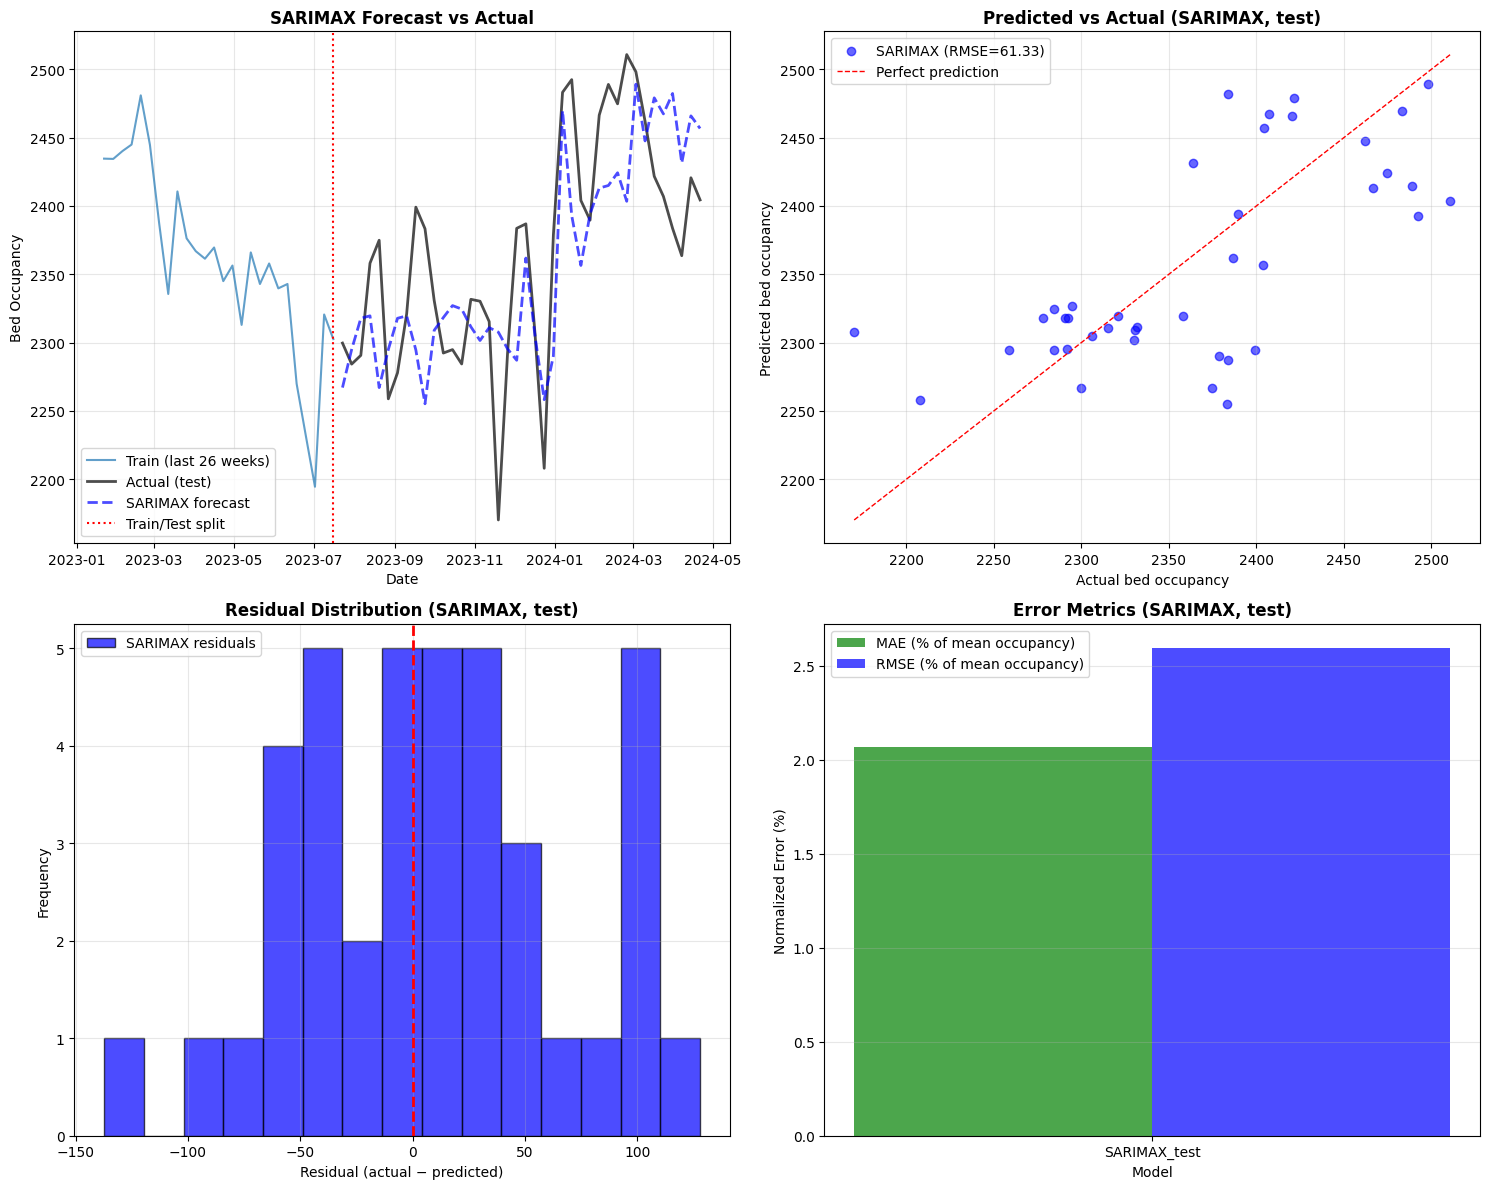

✓ Saved to local: /content/hospital_occupancy_forecasting/models/sarimax_forecast.csv
✓ Saved to Google Drive: /content/drive/MyDrive/hospital_occupancy_forecasting/models/sarimax_forecast.csv

✓ SARIMAX visualizations generated and saved
✓ SARIMAX forecast DataFrame saved
  Expected training time: ~3-5 minutes (optimized for accuracy)


In [49]:
# ============================================================================
# ARIMAX & SARIMAX MODEL EVALUATION METRICS
# ============================================================================

from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.stats.diagnostic import acorr_ljungbox

def calculate_mape(y_true, y_pred):
    """Calculate Mean Absolute Percentage Error."""
    mask = y_true != 0
    if mask.sum() == 0:
        return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def calculate_mase(y_true, y_pred, training_series, seasonality=SARIMAX_SEASONAL_PERIOD):
    """Mean Absolute Scaled Error using seasonal naive baseline."""
    if training_series is None or len(training_series) <= seasonality:
        return np.nan
    train_values = np.asarray(training_series)
    diffs = np.abs(train_values[seasonality:] - train_values[:-seasonality])
    if len(diffs) == 0:
        return np.nan
    scale = np.mean(diffs)
    if scale == 0:
        return np.nan
    return np.mean(np.abs(y_true - y_pred)) / scale

def compute_horizon_errors(y_true, y_pred, horizons=(1, 2, 4)):
    """Compute horizon-specific MAE and RMSE for select lead times."""
    horizon_metrics = {}
    for h in horizons:
        if len(y_true) >= h and len(y_pred) >= h:
            err = y_true[h - 1] - y_pred[h - 1]
            horizon_metrics[h] = {
                "MAE": float(np.abs(err)),
                "RMSE": float(np.sqrt(err**2))
            }
    return horizon_metrics

results = {}
train_results = {}

# =======================
# TEST METRICS (SARIMAX)
# =======================
if sarimax_forecast is not None and len(test_data) > 0:
    forecast_aligned = sarimax_forecast.reindex(test_data.index)
    mask = ~(forecast_aligned.isna() | test_data.isna())
    if mask.sum() > 0:
        y_true_test = test_data[mask].values
        y_pred_test = forecast_aligned[mask].values

        mae_te = mean_absolute_error(y_true_test, y_pred_test)
        rmse_te = np.sqrt(mean_squared_error(y_true_test, y_pred_test))
        mape_te = calculate_mape(y_true_test, y_pred_test)
        mase_te = calculate_mase(y_true_test, y_pred_test, train_data.values if len(train_data) > 0 else None)
        bias_te = float(np.mean(y_pred_test - y_true_test))
        horizon_te = compute_horizon_errors(y_true_test, y_pred_test)

        lb_pvalue_te = np.nan
        try:
            if len(y_true_test) >= 10:
                lb_df = acorr_ljungbox(y_true_test - y_pred_test, lags=[min(10, len(y_true_test) // 2)], return_df=True)
                lb_pvalue_te = float(lb_df["lb_pvalue"].iloc[0])
        except Exception:
            lb_pvalue_te = np.nan

        results['SARIMAX_test'] = {
            'MAE': mae_te,
            'RMSE': rmse_te,
            'MAPE': mape_te,
            'MASE': mase_te,
            'Bias': bias_te,
            'Residual_AC_pvalue': lb_pvalue_te,
            'Horizon_1w_MAE': horizon_te.get(1, {}).get("MAE", np.nan),
            'Horizon_2w_MAE': horizon_te.get(2, {}).get("MAE", np.nan),
            'Horizon_4w_MAE': horizon_te.get(4, {}).get("MAE", np.nan),
            'Horizon_1w_RMSE': horizon_te.get(1, {}).get("RMSE", np.nan),
            'Horizon_2w_RMSE': horizon_te.get(2, {}).get("RMSE", np.nan),
            'Horizon_4w_RMSE': horizon_te.get(4, {}).get("RMSE", np.nan),
            'n': mask.sum(),
        }

# =======================
# TRAINING METRICS (SARIMAX)
# =======================
if sarimax_model is not None and len(train_data) > 0:
    try:
        # Prefer aligned training series if available
        try:
            train_y = train_data_aligned
        except NameError:
            train_y = train_data

        # Use SARIMAX exogenous matrix if available
        X_train_in = None
        try:
            X_train_in = X_train
        except NameError:
            X_train_in = None

        if len(train_y) > 0:
            if X_train_in is not None:
                train_pred_vals = sarimax_model.predict_in_sample(exogenous=X_train_in)
            else:
                train_pred_vals = sarimax_model.predict_in_sample()

            # Align predictions length to train_y defensively
            if len(train_pred_vals) != len(train_y):
                train_pred_series = pd.Series(train_pred_vals[-len(train_y):], index=train_y.index)
            else:
                train_pred_series = pd.Series(train_pred_vals, index=train_y.index)

            mask_tr = ~(train_pred_series.isna() | train_y.isna())
            if mask_tr.sum() > 0:
                y_true_tr = train_y[mask_tr].values
                y_pred_tr = train_pred_series[mask_tr].values

                mae_tr = mean_absolute_error(y_true_tr, y_pred_tr)
                rmse_tr = np.sqrt(mean_squared_error(y_true_tr, y_pred_tr))
                mape_tr = calculate_mape(y_true_tr, y_pred_tr)
                mase_tr = calculate_mase(y_true_tr, y_pred_tr, train_data.values if len(train_data) > 0 else None)
                bias_tr = float(np.mean(y_pred_tr - y_true_tr))

                lb_pvalue_tr = np.nan
                try:
                    if len(y_true_tr) >= 10:
                        lb_df_tr = acorr_ljungbox(y_true_tr - y_pred_tr, lags=[min(10, len(y_true_tr) // 2)], return_df=True)
                        lb_pvalue_tr = float(lb_df_tr["lb_pvalue"].iloc[0])
                except Exception:
                    lb_pvalue_tr = np.nan

                train_results['SARIMAX_train'] = {
                    'MAE': mae_tr,
                    'RMSE': rmse_tr,
                    'MAPE': mape_tr,
                    'MASE': mase_tr,
                    'Bias': bias_tr,
                    'Residual_AC_pvalue': lb_pvalue_tr,
                    'n': mask_tr.sum(),
                }
    except Exception as e:
        print(f"⚠️  Could not compute SARIMAX training metrics: {e}")

# =======================
# PRINT METRICS TABLE
# =======================
if results:
    print("="*80)
    print("SARIMAX MODEL - TRAINING & TEST EVALUATION METRICS")
    print("="*80)
    print(f"\nTest period: {len(test_data)} weeks")
    print(f"Date range (test): {test_data.index.min()} to {test_data.index.max()}\n")

    header = f"{'Set':<12} {'MAE':<10} {'RMSE':<10} {'MAPE (%)':<12} {'MASE':<10} {'Bias':<10} {'n':<8}"
    print(header)
    print("-"*100)

    # Training row
    if 'SARIMAX_train' in train_results:
        m_tr = train_results['SARIMAX_train']
        mape_tr_str = f"{m_tr['MAPE']:.2f}" if not np.isnan(m_tr['MAPE']) else "N/A"
        mase_tr_str = f"{m_tr['MASE']:.2f}" if not np.isnan(m_tr['MASE']) else "N/A"
        print(f"{'Train':<12} {m_tr['MAE']:<10.2f} {m_tr['RMSE']:<10.2f} "
              f"{mape_tr_str:<12} {mase_tr_str:<10} {m_tr['Bias']:<10.2f} {m_tr['n']:<8d}")
    else:
        print(f"{'Train':<12} {'-':<10} {'-':<10} {'-':<12} {'-':<10} {'-':<10} {'-':<8}")

    # Test row
    m_te = results['SARIMAX_test']
    mape_te_str = f"{m_te['MAPE']:.2f}" if not np.isnan(m_te['MAPE']) else "N/A"
    mase_te_str = f"{m_te['MASE']:.2f}" if not np.isnan(m_te['MASE']) else "N/A"
    print(f"{'Test':<12} {m_te['MAE']:<10.2f} {m_te['RMSE']:<10.2f} "
          f"{mape_te_str:<12} {mase_te_str:<10} {m_te['Bias']:<10.2f} {m_te['n']:<8d}")

    # Horizon-aware metrics display
    print("\nHorizon-specific errors (absolute values, test only):")
    print(f"{'Model':<12} {'1w MAE':<10} {'2w MAE':<10} {'4w MAE':<10} {'1w RMSE':<10} {'2w RMSE':<10} {'4w RMSE':<10}")
    print("-"*100)
    def fmt(value):
        return f"{value:.2f}" if not np.isnan(value) else "N/A"
    print(
        f"{'Test':<12} "
        f"{fmt(m_te['Horizon_1w_MAE']):<10} {fmt(m_te['Horizon_2w_MAE']):<10} {fmt(m_te['Horizon_4w_MAE']):<10} "
        f"{fmt(m_te['Horizon_1w_RMSE']):<10} {fmt(m_te['Horizon_2w_RMSE']):<10} {fmt(m_te['Horizon_4w_RMSE']):<10}"
    )

    # Save test metrics
    results_df = pd.DataFrame({'SARIMAX_test': m_te}).T
    results_df = results_df[
        [
            "MAE", "RMSE", "MAPE", "MASE", "Bias", "Residual_AC_pvalue",
            "Horizon_1w_MAE", "Horizon_2w_MAE", "Horizon_4w_MAE",
            "Horizon_1w_RMSE", "Horizon_2w_RMSE", "Horizon_4w_RMSE",
            "n"
        ]
    ]
    save_file(results_df, 'sarimax_evaluation.csv', MODELS_PATH, DRIVE_MODELS_PATH)
    print(f"\n✓ Test evaluation metrics saved to sarimax_evaluation.csv")
else:
    print("⚠️  Cannot evaluate: No SARIMAX forecast available")


# ============================================================================
# COMPREHENSIVE VISUALIZATIONS (Similar to Random Forest)
# ============================================================================
print("\n" + "="*80)
print("GENERATING SARIMAX FORECAST VISUALIZATIONS")
print("="*80)
print("Plot 1 (top-left): Time series of last ~26 train weeks, full test period, and SARIMAX forecast.")
print("  → Use this to assess bias, drift, and how well the model tracks seasonal patterns.\n")
print("Plot 2 (top-right): Predicted vs actual scatter for the test period with a 45° reference line.")
print("  → Points near the diagonal indicate good calibration; systematic offsets indicate bias.\n")
print("Plot 3 (bottom-left): Histogram of residuals (actual − predicted) on the test set.")
print("  → Ideally centered at zero with roughly symmetric spread; skew or heavy tails indicate issues.\n")
print("Plot 4 (bottom-right): Normalized MAE and RMSE (as % of mean occupancy) for SARIMAX.")
print("  → Lets you interpret error size relative to typical bed occupancy.\n")

# Prepare data for plotting
forecasts_to_plot = {}
if sarimax_forecast is not None:
    forecasts_to_plot['SARIMAX'] = sarimax_forecast

if forecasts_to_plot and len(test_data) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))

    # Plot 1: Forecast comparison (top left)
    ax1 = axes[0, 0]
    train_display = min(26, len(train_data))
    ax1.plot(train_data.index[-train_display:], train_data.values[-train_display:],
             label=f'Train (last {train_display} weeks)', alpha=0.7, linewidth=1.5)
    ax1.plot(test_data.index, test_data.values, label='Actual (test)', alpha=0.7,
             color='black', linewidth=2)

    colors = ['blue']
    for i, (model_name, forecast) in enumerate(forecasts_to_plot.items()):
        forecast_aligned = forecast.reindex(test_data.index)
        mask = ~forecast_aligned.isna()
        if mask.sum() > 0:
            ax1.plot(test_data.index[mask], forecast_aligned[mask],
                    label=f'{model_name} forecast', alpha=0.7, linestyle='--',
                    color=colors[i % len(colors)], linewidth=2)

    ax1.axvline(x=train_data.index[-1], color='red', linestyle=':', label='Train/Test split')
    ax1.set_title('SARIMAX Forecast vs Actual', fontweight='bold')
    ax1.set_xlabel('Date')
    ax1.set_ylabel('Bed Occupancy')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Plot 2: Scatter plots (top right)
    ax2 = axes[0, 1]
    for i, (model_name, forecast) in enumerate(forecasts_to_plot.items()):
        forecast_aligned = forecast.reindex(test_data.index)
        mask = ~(forecast_aligned.isna() | test_data.isna())
        if mask.sum() > 0:
            y_true = test_data[mask].values
            y_pred = forecast_aligned[mask].values
            rmse_label = results.get('SARIMAX_test', {}).get('RMSE', np.nan)
            label = f'{model_name} (RMSE={rmse_label:.2f})' if not np.isnan(rmse_label) else model_name
            ax2.scatter(y_true, y_pred, alpha=0.6, color=colors[i % len(colors)],
                       label=label)

            min_val = min(y_true.min(), y_pred.min())
            max_val = max(y_true.max(), y_pred.max())
            ax2.plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect prediction', linewidth=1)

    ax2.set_title('Predicted vs Actual (SARIMAX, test)', fontweight='bold')
    ax2.set_xlabel('Actual bed occupancy')
    ax2.set_ylabel('Predicted bed occupancy')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    # Plot 3: Residuals comparison (bottom left)
    ax3 = axes[1, 0]
    for i, (model_name, forecast) in enumerate(forecasts_to_plot.items()):
        forecast_aligned = forecast.reindex(test_data.index)
        mask = ~(forecast_aligned.isna() | test_data.isna())
        if mask.sum() > 0:
            y_true = test_data[mask].values
            y_pred = forecast_aligned[mask].values
            residuals = y_true - y_pred
            ax3.hist(residuals, bins=15, alpha=0.7, color=colors[i % len(colors)],
                    label=f'{model_name} residuals', edgecolor='black')

    ax3.axvline(x=0, color='r', linestyle='--', linewidth=2)
    ax3.set_title('Residual Distribution (SARIMAX, test)', fontweight='bold')
    ax3.set_xlabel('Residual (actual − predicted)')
    ax3.set_ylabel('Frequency')
    ax3.legend()
    ax3.grid(True, alpha=0.3)

    # Plot 4: Error metrics comparison (bottom right)
    ax4 = axes[1, 1]
    if results:
        metrics_df = pd.DataFrame({'SARIMAX_test': results['SARIMAX_test']}).T
        mean_actual = test_data.mean()
        mae_normalized = metrics_df['MAE'] / mean_actual * 100
        rmse_normalized = metrics_df['RMSE'] / mean_actual * 100

        x_pos = np.arange(len(metrics_df))
        width = 0.35
        ax4.bar(x_pos - width/2, mae_normalized, width,
                label='MAE (% of mean occupancy)', alpha=0.7, color='green')
        ax4.bar(x_pos + width/2, rmse_normalized, width,
                label='RMSE (% of mean occupancy)', alpha=0.7, color='blue')
        ax4.set_xlabel('Model')
        ax4.set_ylabel('Normalized Error (%)')
        ax4.set_title('Error Metrics (SARIMAX, test)', fontweight='bold')
        ax4.set_xticks(x_pos)
        ax4.set_xticklabels(metrics_df.index)
        ax4.legend()
        ax4.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    save_plot(plt.gcf(), 'sarimax_model_results.png', RESULTS_PATH, DRIVE_RESULTS_PATH,
             dpi=300, bbox_inches='tight')
    plt.show()

    # Save SARIMAX forecast DataFrame
    for model_name, forecast in forecasts_to_plot.items():
        forecast_df = pd.DataFrame({
            'actual': test_data.reindex(forecast.index).values,
            'predicted': forecast.values
        }, index=forecast.index)
        save_file(forecast_df, 'sarimax_forecast.csv', MODELS_PATH, DRIVE_MODELS_PATH)

    print("\n✓ SARIMAX visualizations generated and saved")
    print("✓ SARIMAX forecast DataFrame saved")
else:
    print("⚠️  Cannot generate SARIMAX visualizations: No forecast or test data available")

print("  Expected training time: ~3-5 minutes (optimized for accuracy)")